In [2]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import matplotlib.colors as mcolors
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp

%load_ext autoreload
%autoreload 2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
python3.10(31566) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarnin

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    

}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])

In [21]:
obs = adata.obs

In [22]:
# make font changeable in Illustrator
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

# use colorblind seaborn style

# By MN

In [39]:
from tqdm import tqdm
'''unique_samples = np.unique(adata_obs.Sample)
mn = []

MN_names = []
for i, grp in  adata_obs.groupby('CombinedNameMerge'):
    print(i)
    if i.count('unknown') == 0:
        MN_names.append(i)
        mn.append([grp.Area[grp.Sample == s].sum() for s in unique_samples])'''
obs['Patient'] = [x[:5] for x in obs['Sample']]
df_table = obs.pivot_table(values='Area', index='Patient', columns='m-states', aggfunc=np.mean)
df_table = df_table.drop(columns=['unknown'])

/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_21390/2644318121.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_table = obs.pivot_table(values='Area', index='Patient', columns='m-states', aggfunc=np.mean)
/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_21390/2644318121.py:12: FutureWarning: The provided callable <function mean at 0x104593010> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_table = obs.pivot_table(values='Area', index='Patient', columns='m-states', aggfunc=np.mean)


In [40]:
adata.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'DC', 'Endothelial',
       'Erythrocyte', 'FB-like 1', 'FB-like 2', 'FB-like 3', 'GBL-like 1',
       'GBL-like 2', 'Mono 1', 'Mono 2', 'Mural cell 1', 'Mural cell 2',
       'OPC-like 1', 'OPC-like 2', 'Oligodendrocyte', 'RG-like', 'TAM-BDM 1',
       'TAM-BDM 2', 'TAM-BDM 3', 'TAM-BDM 4', 'TAM-MG', 'WR Endo.Ass.',
       'WR HYPR1', 'WR HYPR2', 'WR OPC', 'WR Periphery1', 'WR Periphery2',
       'WR Periphery3', 'WR nIPC', 'nIPC-RG-like', 'nIPC-like 1',
       'nIPC-like 2', 'nIPC-like 3', 'preOPC-like', 'unknown'],
      dtype='object')

In [41]:
order = [
    'AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5', 'AC-like 6', 'AC-like 7',
    'GBL-like 1', 'GBL-like 2',
    'preOPC-like', 
    'OPC-like 1', 'OPC-like 2',
    'RG-like','nIPC-RG-like',
    'nIPC-like 1', 'nIPC-like 2' , 'nIPC-like 3',
    'FB-like 1', 'FB-like 2', 'FB-like 3',
    'WR HYPR1', 'WR HYPR2', 'WR OPC', 'WR Periphery1', 'WR Periphery2','WR Periphery3', 'WR nIPC',
    
    'Mono 1', 'Mono 2',
    'TAM-BDM 1','TAM-BDM 2','TAM-BDM 3','TAM-BDM 4',
    'TAM-MG',
    'DC',
    #'Plasma B 1','Plasma B 2','Plasma B 3',
    'Oligodendrocyte',
    'Mural cell 1','Mural cell 2',
    'Endothelial',
    'Erythrocyte',
    
    
][::-1]
df_table = df_table.loc[:,order]

order = order[::-1]

from sklearn.preprocessing import Normalizer, StandardScaler

#X = np.array(df_table.values)
#X = Normalizer().fit_transform(X)
df_table = df_table.T
df_table = (df_table/df_table.sum(axis=1).values[:,None]) * 100
#scaler = StandardScaler()
#vals = scaler.fit_transform(df_table)
vals = df_table.values
df = pd.DataFrame(data=vals,index=df_table.index, columns= df_table.columns)
df = df.T

In [42]:
df = df.fillna(0)

In [43]:
import scipy.cluster.hierarchy as hc
from scipy.spatial.distance import pdist
from sklearn.preprocessing import scale
from scipy.cluster.hierarchy import dendrogram
import fastcluster

metric='euclidean'
method = 'ward'

#df_means= pd.DataFrame(data=reference_means.X,index=reference_means.obs.annotation )

D = pdist(df.values, metric)
#D = pdist(df.values, metric)
Z = fastcluster.linkage(D, method=method,metric=metric, preserve_input=True)
Z = hc.optimal_leaf_ordering(Z, D, metric=metric)
ordering_sc = hc.leaves_list(Z)
#ordering_sc_str = df.columns[ordering_sc]
ordering_samples = df.index[ordering_sc][::-1]
ordering_samples

Index(['SL047', 'SL040', 'SL037', 'SL046', 'SL057', 'SL035', 'SL053', 'SL023',
       'SL030', 'SL013', 'SL005', 'SL011', 'SL001', 'SL006', 'SL019', 'SL038',
       'SL034', 'SL027', 'SL002', 'SL018', 'SL012', 'SL003', 'SL015', 'SL061',
       'SL029', 'SL020', 'SL016'],
      dtype='object', name='Patient')

In [44]:
order_abb = [
    'AC1', 'AC2', 'AC3', 'AC4', 'AC5', 'AC6', 'AC7',
    'GBL1', 'GBL2',
    'preOPC', 
    'OPC1', 'OPC2',
    'RG','nIPC-RG',
    'nIPC1', 'nIPC2' , 'nIPC3',
    'FB1', 'FB2', 'FB3',
    'WR HYPR1', 'WR HYPR2', 'WR OPC', 'WR Periphery1', 'WR Periphery2','WR Periphery3', 'WR nIPC',
    
    'Mono 1', 'Mono 2',
    'TAM-BDM 1','TAM-BDM 2','TAM-BDM 3','TAM-BDM 4',
    'TAM-MG',
    'DC',
    #'Plasma B 1','Plasma B 2','Plasma B 3',
    'OL',
    'Mural 1','Mural 2',
    'Endo.',
    'Ery.',
    
    
][::-1]

In [45]:
df = df.loc[ordering_samples]

In [46]:
df

m-states,Erythrocyte,Endothelial,Mural cell 2,Mural cell 1,Oligodendrocyte,DC,TAM-MG,TAM-BDM 4,TAM-BDM 3,TAM-BDM 2,...,preOPC-like,GBL-like 2,GBL-like 1,AC-like 7,AC-like 6,AC-like 5,AC-like 4,AC-like 3,AC-like 2,AC-like 1
Patient,,,,,,,,,,,,,,,,,,,,,
SL047,7.176416,4.810895,10.977434,10.284960,5.369557,0.000000,0.000000,6.533334,5.434028,6.013198,...,3.776362,5.001833,5.759799,7.195066,2.525014,4.734159,0.000000,4.473971,6.309651,6.793596
SL040,4.594547,6.183171,3.178033,4.103349,5.936316,0.000000,8.267980,2.608627,6.116553,3.479071,...,7.686641,4.122471,3.312602,5.090255,5.618028,4.714318,5.393976,4.533925,8.781939,5.104902
SL037,5.550907,4.785506,5.556859,4.100777,2.609749,0.000000,3.380719,4.008109,2.953746,4.104054,...,2.319734,2.519292,3.471189,3.530918,3.879828,5.183070,11.421591,4.030758,3.269507,4.091543
SL046,2.153753,3.462232,3.971063,3.021052,5.742146,0.000000,3.709521,3.664283,5.233242,3.073885,...,1.200955,2.150940,1.687301,2.737813,3.032818,4.727429,6.627251,4.058702,3.705029,3.320888
SL057,4.808808,4.291078,6.551735,4.206798,7.279954,0.000000,3.402579,4.598902,5.968433,4.127743,...,2.119779,2.578011,3.461831,4.224278,3.142034,3.753163,8.961691,3.539458,4.096857,5.164072
SL035,5.801810,2.195230,4.593159,4.095595,3.839884,5.754540,2.175200,4.013748,2.087240,2.355829,...,3.138967,4.115172,2.197587,2.366052,3.933853,2.380102,14.394599,4.824040,4.717339,3.002909
SL053,5.020013,2.005806,3.645198,3.723084,5.723452,13.219388,4.488988,5.476799,7.270909,5.416985,...,2.204026,2.268247,2.525710,5.572981,3.477781,3.612899,10.997176,3.054359,5.276401,6.211443
SL023,6.522860,4.184588,4.181868,6.411871,1.197285,9.686465,2.386137,1.834937,1.723089,1.642959,...,1.193446,1.422847,2.351294,2.136575,3.757660,1.920078,0.000000,3.311548,2.146510,2.284792
SL030,2.000044,2.950586,2.894657,5.617647,2.574541,16.339947,3.356054,0.000000,1.705513,2.312877,...,2.514951,1.575564,2.421649,2.189974,3.099460,3.143707,0.000000,4.027499,1.666965,2.678242


In [47]:
df.index

Index(['SL047', 'SL040', 'SL037', 'SL046', 'SL057', 'SL035', 'SL053', 'SL023',
       'SL030', 'SL013', 'SL005', 'SL011', 'SL001', 'SL006', 'SL019', 'SL038',
       'SL034', 'SL027', 'SL002', 'SL018', 'SL012', 'SL003', 'SL015', 'SL061',
       'SL029', 'SL020', 'SL016'],
      dtype='object', name='Patient')

In [48]:
vals.shape

(40, 27)

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'W', 'Y', 'a', 'd', 'e', 'eight', 'five', 'four', 'h', 'hyphen', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 'seven', 'six', 'space', 'three', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 39, 40, 41, 42, 43, 44, 47, 48, 50, 51, 53, 54, 55, 58, 60, 68, 71, 72, 75, 76, 79, 81, 82, 83, 85, 88, 92]
INFO:

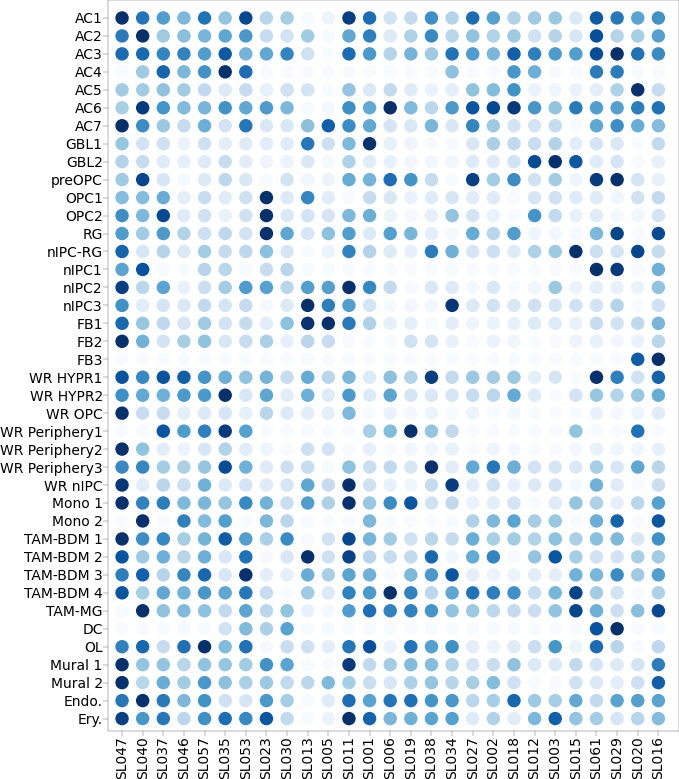

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Create a figure and axis
figsize=(7,8)
fig, ax = plt.subplots(figsize=figsize)

# Set the size of the dots
dot_size = 75

# Iterate over each row and column
for x in df.columns:
    
    vals = df[x].values
    ax.scatter(df.index, [x]*df.index.shape[0] ,s=dot_size, c=vals, cmap='Blues',)#norm=mcolors.CenteredNorm()

# Set the axis limits
ax.set_xlim([-1, 41])
ax.set_ylim([-1, 10])

# Show the colorbar
#cbar = plt.colorbar()
# Set the colorbar label
#cbar.set_label('Values')
ax.set_yticks(range(df.shape[1]), order_abb, rotation=0, fontsize=10)
ax.set_xticks(range(df.shape[0]), df.index, rotation=90, fontsize=10)
#ax.set_yticks(range(df.shape[0]), ['CN'+str(x+1) for x in range(10)], fontsize=10, rotation=0)

ax.set_xlim(-.1*figsize[0], len(df.index))
ax.set_ylim(-.1*figsize[0], len(df.columns))
#plt.axis('off')

#ax.spines[['top','bottom','left','right']].set_visible(False)# Show the plot
plt.tight_layout()
#plt.grid(axis='y')
plt.savefig('figures/MN_Patient.pdf',dpi=600,transparent=True)
plt.show()